In [9]:
from solver_selection_thm.physics import ModelTHM, initialize, run, params
from solver_selection_thm.selector import SolverSelector
from solver_selection_thm.solver_space import CategoricalChoices, NumericalChoices
from solver_selection_thm.performance_predictor import (
    PerformancePredictorPassiveAgressive,
    PerformancePredictorEpsGreedy,
    RewardEstimator,
)
from solver_selection_thm.solver_space import SolverSpace
from solver_selection_thm.pp_binding import (
    KNOWN_SOLVER_COMPONENTS_THM,
    SolverSelectionMixinTHM,
)
from thm_runscript import make_solver_space_scheme_fthm
import numpy as np
from matplotlib import pyplot as plt

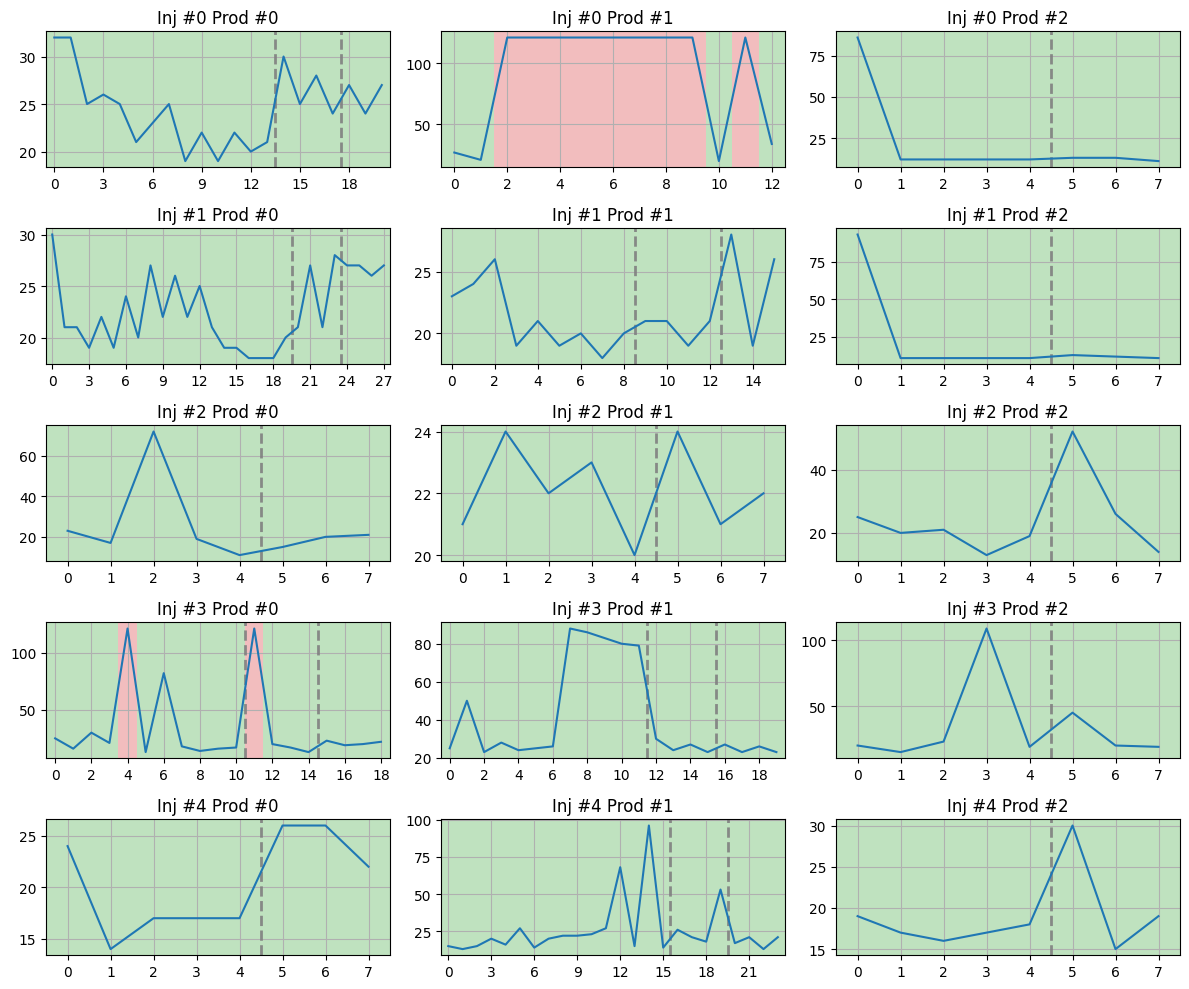

In [26]:
from itertools import count
from plot_utils import (
    color_converged_reason,
    color_time_steps,
    get_gmres_iterations,
    load_data,
    get_cfl,
    get_enthalpy_max,
    get_peclet_max,
    get_temp_max,
    get_temp_min,
    get_num_sticking_sliding_open,
    get_linear_solve_time
)
from solver_selection_thm.spe_physics import X_SLICES, Z_SLICES, simulation_name, params


data_simulations = []
# solver_selection_history = []

np.random.seed(42)
run_idx = 0
np.random.shuffle(Z_SLICES)
np.random.shuffle(X_SLICES)

for z_slice in Z_SLICES:
    data_row = []
    data_simulations.append(data_row)
    for x_slice in X_SLICES:
        params["x_slice"] = x_slice
        params["z_slice"] = z_slice
        sim_name = f"run_{run_idx}_{simulation_name(params)}"
        try:
            data = load_data(f"../stats/{sim_name}.json")
            # solver_selection_history.append()
            data_row.append(data)
        except FileNotFoundError:
            data_row.append(None)


fig, axes = plt.subplots(
    nrows=len(Z_SLICES), ncols=len(X_SLICES), figsize=(12, 10)
)
for i, data_row in enumerate(data_simulations):
    for j, data in enumerate(data_row):
        if data == None:
            continue
        ax = axes[i][j]
        plt.sca(ax)

        color_converged_reason(data)
        color_time_steps(data)

        ax.plot(get_gmres_iterations(data))
        # ax.set_yscale('log')
        # print(inlet_placement, outlet_placement)
        ax.set_title(f"Inj #{i} Prod #{j}")

plt.tight_layout()

In [21]:
from spe_runscript import make_solver_space_scheme_hm

solver_space = SolverSpace(
    solver_space_scheme=make_solver_space_scheme_hm(nd=3),
    solver_scheme_builders=KNOWN_SOLVER_COMPONENTS_THM,
)
num_solvers = len(solver_space.all_decisions_encoding)
print(solver_space.decision_tree)
print("Num solvers:", num_solvers)

performance_predictor = PerformancePredictorPassiveAgressive(
    num_solvers=num_solvers,
)
solver_selector = SolverSelector(
    reward_estimator=RewardEstimator(),
    solver_space=solver_space,
    performance_predictor=performance_predictor,
)

block_type: PetscKSPScheme
| ksp_gmres_restart: Choices from 10 to 50, len = 3
| block_type (fork with 2 branches):
| | block_type: PetscFieldSplitScheme
| | | elim_options (fork with 4 branches):
| | | | python_pc_type: ilu
| | | | | python_pc_factor_levels: Choices from 0 to 2, len = 3
| | | | python_pc_type: sor
| | | | python_pc_type: pbjacobi
| | | | python_pc_type: hypre
| | | | | python_pc_hypre_boomeramg_strong_threshold: Choices from 0.5 to 0.9, len = 3
| | | | | python_pc_hypre_boomeramg_agg_nl: Choices from 0 to 2, len = 3
| | | | | python_pc_hypre_boomeramg_relax_type_all (fork with 4 branches):
| | | | | | symmetric-SOR/Jacobi
| | | | | | l1scaled-Jacobi
| | | | | | SOR/Jacobi
| | | | | | Jacobi
| | block_type: PetscCompositeScheme
| | | pc_hypre_boomeramg_strong_threshold: Choices from 0.5 to 0.9, len = 3
| | | pc_hypre_boomeramg_agg_nl: Choices from 0 to 2, len = 3
| | | pc_hypre_boomeramg_relax_type_all (fork with 4 branches):
| | | | symmetric-SOR/Jacobi
| | | | l1scal

In [24]:
solver_selector.history.load('../solver_selection_history.npy')
history = solver_selector.history
decision_id = np.array(history.decision_idx)
X, y = np.array(history.features), np.array(history.reward)

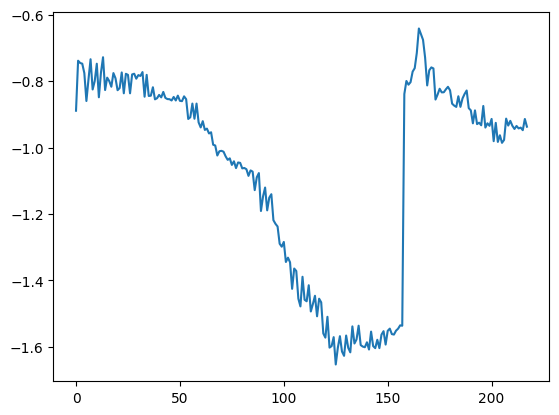

In [25]:
plt.plot(y)